# Customer Segmentation using K-Means Clustering

**Internship Project | CodTech IT Solutions**

### Objective
Segment mall customers into distinct groups based on their **Age**, **Annual Income**, and **Spending Score** using unsupervised machine learning (K-Means Clustering). This helps a business understand different customer types and design targeted marketing strategies for each group.

### Dataset
`Mall_Customers.csv` — contains CustomerID, Gender, Age, Annual Income (k$), and Spending Score (1-100) for 200 customers.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Load the Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,CustomerID,Gender,Age,Annual_Income_k$,Spending_Score
0,1,Male,25,35,92
1,2,Female,21,15,68
2,3,Female,28,29,88
3,4,Female,18,15,85
4,5,Male,25,19,94


## 2. Exploratory Data Analysis (EDA)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        200 non-null    int64
 1   Gender            200 non-null    str  
 2   Age               200 non-null    int64
 3   Annual_Income_k$  200 non-null    int64
 4   Spending_Score    200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()


,CustomerID,Age,Annual_Income_k$,Spending_Score
count,200.000000,200.000000,200.000000,200.00000
mean,100.500000,35.515000,53.730000,51.50500
std,57.879185,10.385038,25.738287,26.07334
min,1.000000,18.000000,15.000000,5.00000
25%,50.750000,26.750000,32.000000,30.75000
50%,100.500000,36.000000,49.000000,53.50000
75%,150.250000,42.000000,76.250000,74.25000
max,200.000000,64.000000,99.000000,94.00000


In [5]:
# Check for missing values
df.isnull().sum()


CustomerID          0
Gender              0
Age                 0
Annual_Income_k$    0
Spending_Score      0
dtype: int64

/tmp/ipykernel_577/1845629896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette="Set2")


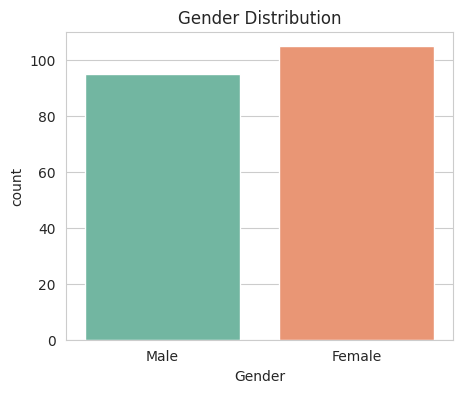

In [6]:
# Gender distribution
plt.figure(figsize=(5,4))
sns.countplot(x="Gender", data=df, palette="Set2")
plt.title("Gender Distribution")
plt.show()


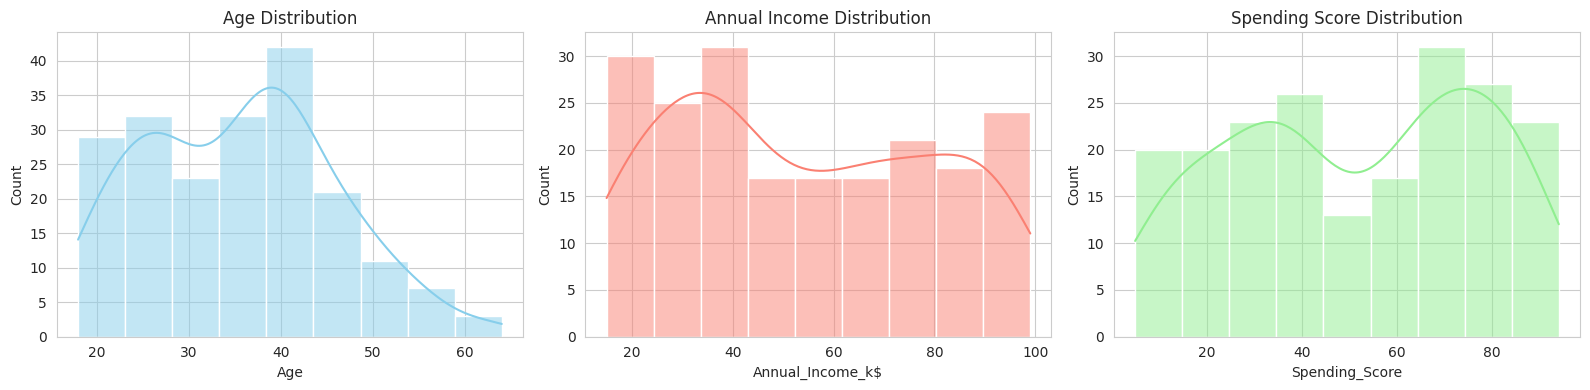

In [7]:
# Distribution of Age, Annual Income, Spending Score
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Age"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Age Distribution")

sns.histplot(df["Annual_Income_k$"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Annual Income Distribution")

sns.histplot(df["Spending_Score"], kde=True, ax=axes[2], color="lightgreen")
axes[2].set_title("Spending Score Distribution")

plt.tight_layout()
plt.show()


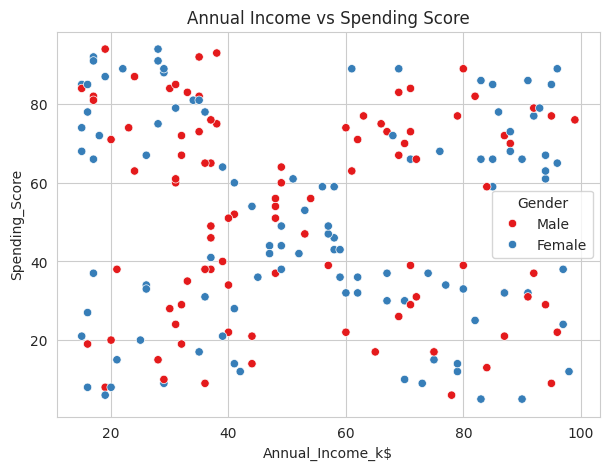

In [8]:
# Relationship between Annual Income and Spending Score
plt.figure(figsize=(7,5))
sns.scatterplot(x="Annual_Income_k$", y="Spending_Score", data=df, hue="Gender", palette="Set1")
plt.title("Annual Income vs Spending Score")
plt.show()


## 3. Data Preprocessing

We'll encode the categorical `Gender` column and scale the numeric features so that K-Means (which relies on distance) treats all features fairly.

In [9]:
le = LabelEncoder()
df["Gender_encoded"] = le.fit_transform(df["Gender"])  # Female=0, Male=1

features = df[["Annual_Income_k$", "Spending_Score"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features[:5]


array([[-0.72953579,  1.55701642],
       [-1.50853824,  0.6342261 ],
       [-0.96323653,  1.40321803],
       [-1.50853824,  1.28786924],
       [-1.35273775,  1.63391561]])

## 4. Finding the Optimal Number of Clusters

### 4.1 Elbow Method
We plot WCSS (Within-Cluster Sum of Squares) against the number of clusters (k) and look for the "elbow" point.

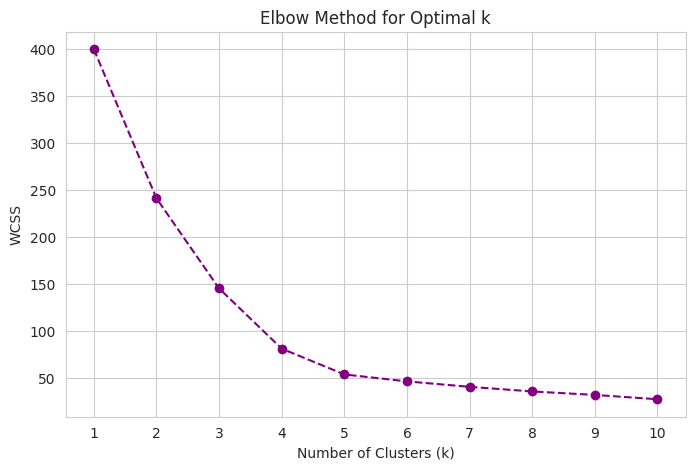

In [10]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker="o", linestyle="--", color="purple")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.xticks(K_range)
plt.show()


### 4.2 Silhouette Score (extra validation)
Higher silhouette score (closer to 1) means better-defined clusters.

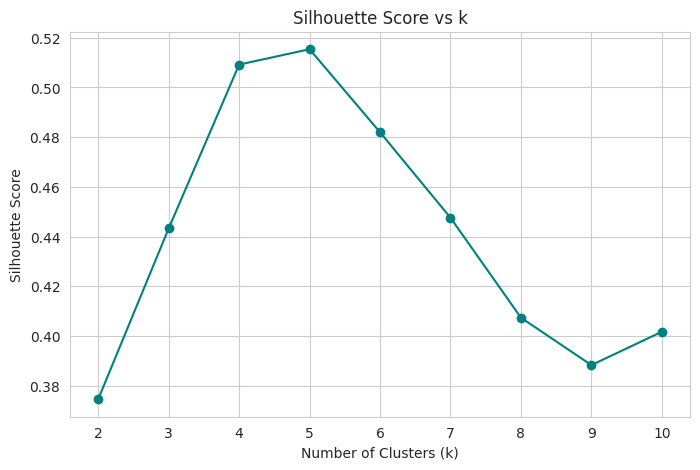

Best k according to silhouette score: 5


In [11]:
sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    sil_scores.append(silhouette_score(scaled_features, labels))

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), sil_scores, marker="o", color="teal")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

best_k = range(2, 11)[np.argmax(sil_scores)]
print(f"Best k according to silhouette score: {best_k}")


Based on the elbow curve and silhouette score, **k = 5** gives well-separated, business-interpretable clusters, so we'll go with that.

## 5. Applying K-Means Clustering

In [12]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_features)

df.head()


,CustomerID,Gender,Age,Annual_Income_k$,Spending_Score,Gender_encoded,Cluster
0,1,Male,25,35,92,1,2
1,2,Female,21,15,68,0,2
2,3,Female,28,29,88,0,2
3,4,Female,18,15,85,0,2
4,5,Male,25,19,94,1,2


## 6. Visualizing the Customer Segments

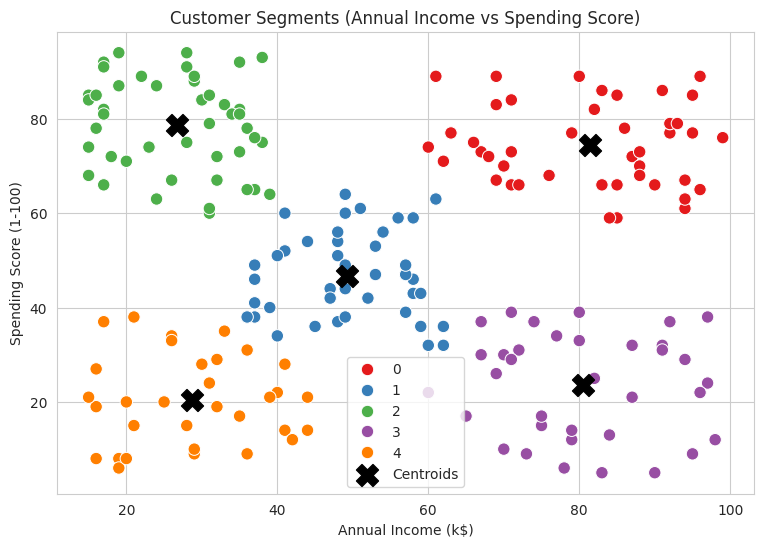

In [13]:
plt.figure(figsize=(9,6))
palette = sns.color_palette("Set1", optimal_k)

sns.scatterplot(
    x="Annual_Income_k$", y="Spending_Score",
    hue="Cluster", data=df, palette=palette, s=80, legend="full"
)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], s=250, c="black", marker="X", label="Centroids")

plt.title("Customer Segments (Annual Income vs Spending Score)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()


## 7. Cluster Profiling

Let's understand what each cluster actually represents so we can label them meaningfully.

In [14]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual_Income_k$", "Spending_Score"]].mean().round(1)
cluster_summary["Count"] = df["Cluster"].value_counts().sort_index()
cluster_summary


,Age,Annual_Income_k$,Spending_Score,Count
Cluster,,,,
0,33.5,81.4,74.5,44
1,38.4,49.2,46.6,42
2,22.5,26.7,78.7,45
3,40.5,80.5,23.5,37
4,46.9,28.7,20.4,32


In [15]:
# Assign human-readable labels based on the profile
def label_cluster(row):
    income, spend = row["Annual_Income_k$"], row["Spending_Score"]
    if income < 45 and spend > 55:
        return "Young Budget Spenders"
    elif income > 55 and spend > 55:
        return "High Income - High Spenders (Target)"
    elif income > 55 and spend <= 55:
        return "High Income - Cautious Spenders"
    elif income < 45 and spend <= 55:
        return "Low Income - Low Spenders"
    else:
        return "Average Customers"

cluster_summary["Segment_Label"] = cluster_summary.apply(label_cluster, axis=1)
cluster_summary


,Age,Annual_Income_k$,Spending_Score,Count,Segment_Label
Cluster,,,,,
0,33.5,81.4,74.5,44,High Income - High Spenders (Target)
1,38.4,49.2,46.6,42,Average Customers
2,22.5,26.7,78.7,45,Young Budget Spenders
3,40.5,80.5,23.5,37,High Income - Cautious Spenders
4,46.9,28.7,20.4,32,Low Income - Low Spenders


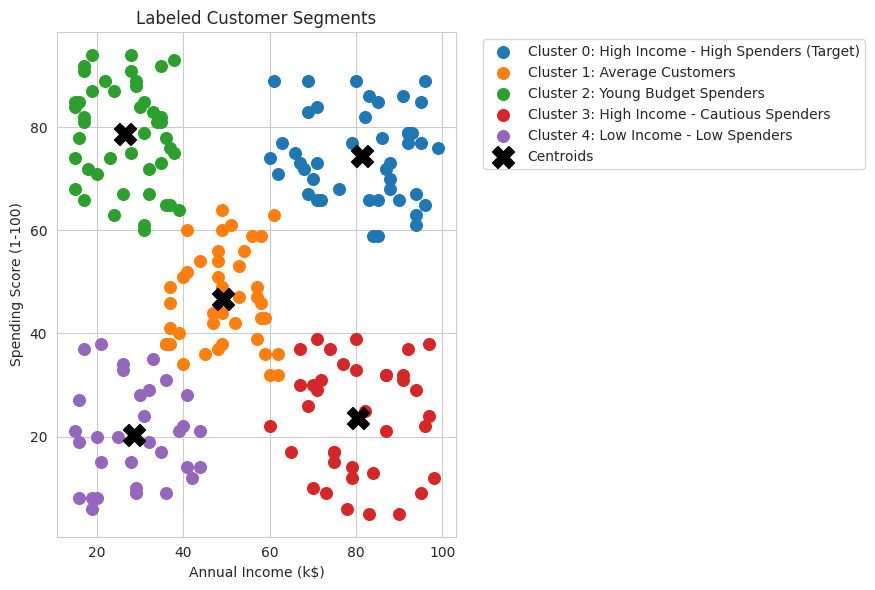

In [16]:
plt.figure(figsize=(9,6))
for cluster_id in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == cluster_id]
    label = cluster_summary.loc[cluster_id, "Segment_Label"]
    plt.scatter(subset["Annual_Income_k$"], subset["Spending_Score"], label=f"Cluster {cluster_id}: {label}", s=70)

plt.scatter(centers[:, 0], centers[:, 1], s=250, c="black", marker="X", label="Centroids")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Labeled Customer Segments")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 8. Business Insights

- **High Income - High Spenders (Target)**: Prime customers — focus premium/loyalty campaigns here.
- **Young Budget Spenders**: Lower income but high spending score — good for trendy, affordable products & offers.
- **High Income - Cautious Spenders**: Spend less despite earning more — potential for personalized upselling.
- **Low Income - Low Spenders**: Least profitable segment — minimal marketing spend recommended here.
- **Average Customers**: Balanced group — general marketing works fine.

## 9. Conclusion

Using K-Means clustering, we successfully segmented 200 mall customers into 5 meaningful groups based on Annual Income and Spending Score. This kind of segmentation helps businesses design **targeted marketing strategies**, optimize **customer retention**, and improve **ROI on marketing spend** by focusing resources on the right customer segments.
